In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df = gene_trait_df.select(['region', 'phenotype', 'loftee_corr_dir'])
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,loftee_corr_dir
str,str,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",-1.0
"""ENSG00000101439""","""cystatin_c_int""",-1.0
"""ENSG00000149948""","""standing_height_int""",-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",1.0
…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",1.0


In [3]:
# EUR unrelated individuals

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/sample_lists/unrelated_cauc_samples_3rd_degree.csv -o /home/dnanexus/data_dir/

unrel_eur_samples = pl.read_csv('/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv')['eid'].cast(pl.Utf8).to_list()
unrel_eur_samples[:5]

Error: path "/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv"
already exists but -f/--overwrite was not set


['1000020', '1000107', '1000161', '1000172', '1000221']

In [4]:
from scipy.special import ndtri

c = 3/8  # Blom's constant for inverse normal transformation (prevents infinite values at the tails)

# Download phenotypes: covariates and PRS corrected
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/phenotypes/corrected_cov_PRS_traits_EUR.parquet -o /home/dnanexus/data_dir/

phenos = (
    pl.read_parquet('/home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquet')
    .rename({'individual':'sample'})
    .filter(pl.col('sample').is_in(unrel_eur_samples))
)

# phenos
long_phenos_int = (
    phenos
    .unpivot(
        index='sample',
        on=gene_trait_df['phenotype'].unique().to_list(),
        variable_name='phenotype',
        value_name='pheno_value'
    )
    .drop_nulls()

    .lazy()  # Use Lazy mode for better memory/query optimization
    .with_columns(
        # Calculate rank and group size using native Rust engine
        r = pl.col("pheno_value").rank().over("phenotype"),
        n = pl.len().over("phenotype")
    )
    .with_columns(
        # Calculate the INT value calling ndtri ONCE on the whole column
        pheno_value_int = ((pl.col("r") - c) / (pl.col("n") - 2*c + 1)).map_batches(ndtri)
    )
    .drop(["r", "n", "pheno_value"]) # Clean up temporary columns

    .join(
        gene_trait_df.lazy(),
        on='phenotype',
        how='inner'
    )
    .collect()
)

print(long_phenos_int['phenotype'].value_counts(sort=True))
long_phenos_int

[===========================================================>] Completed 1,717,336,582 of 1,717,336,582 bytes (100%) /home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquett
shape: (96, 2)
┌─────────────────────────────────┬──────────┐
│ phenotype                       ┆ count    │
│ ---                             ┆ ---      │
│ str                             ┆ u64      │
╞═════════════════════════════════╪══════════╡
│ standing_height_int             ┆ 29114316 │
│ mean_platelet_thrombocyte_volu… ┆ 9926523  │
│ sitting_height_int              ┆ 9444350  │
│ mean_corpuscular_haemoglobin_i… ┆ 7720713  │
│ cystatin_c_int                  ┆ 7224160  │
│ …                               ┆ …        │
│ trunk_fat_mass_int              ┆ 372061   │
│ creatinine_enzymatic_in_urine_… ┆ 368060   │
│ mean_corpuscular_haemoglobin_c… ┆ 367651   │
│ age_started_wearing_glasses_or… ┆ 338512   │
│ testosterone_int                ┆ 327366   │
└─────────────────────────────────┴──────────┘


sample,phenotype,pheno_value_int,region,loftee_corr_dir
str,str,f64,str,f64
"""1000020""","""eosinophill_percentage_int""",-1.620681,"""ENSG00000121966""",-1.0
"""1000020""","""eosinophill_percentage_int""",-1.620681,"""ENSG00000131018""",1.0
"""1000107""","""eosinophill_percentage_int""",-0.235119,"""ENSG00000121966""",-1.0
"""1000107""","""eosinophill_percentage_int""",-0.235119,"""ENSG00000131018""",1.0
"""1000161""","""eosinophill_percentage_int""",-0.441853,"""ENSG00000121966""",-1.0
…,…,…,…,…
"""4301443""","""white_blood_cell_leukocyte_cou…",-0.789672,"""ENSG00000148400""",-1.0
"""2750445""","""white_blood_cell_leukocyte_cou…",-0.556936,"""ENSG00000064932""",1.0
"""2750445""","""white_blood_cell_leukocyte_cou…",-0.556936,"""ENSG00000148400""",-1.0


In [5]:
long_phenos_int.filter(pl.col('phenotype')=='standing_height_int').select(pl.col('pheno_value_int').std())

pheno_value_int
f64
0.999991


In [6]:
mac = 20

RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_DIR}/{ANNO_FILE}

id_list = (
    pl.scan_parquet(f'{LOCAL_DIR}/{ANNO_FILE}')
    .filter(
        pl.col('region').is_in(gene_trait_df.select('region').unique().to_series()),
        pl.col('mac_ukb')<=mac,
        pl.col('loftee_hc')==1,
    )
    .select(['id', 'region'])
    .unique()
    .collect()
)

id_list

[===========================================================>] Completed 7,370,308,270 of 7,370,308,270 bytes (100%) /home/dnanexus/data_dir//annotations_fillna_ukbgym_with_mane.parquett=======================>                                    ] Downloaded 2,936,012,800 of 7,370,308,270 bytes (39%) /home/dnanexus/data_dir//annotations_fillna_ukbgym_with_mane.parquet


/tmp/ipykernel_9457/2409906056.py:19: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region
str,str
"""chr8:8797423:G:A""","""ENSG00000147324"""
"""chr11:48137241:G:GA""","""ENSG00000149177"""
"""chr9:35711669:G:A""","""ENSG00000137076"""
"""chr19:47045532:G:GT""","""ENSG00000130751"""
"""chr6:52072152:T:TA""","""ENSG00000170927"""
…,…
"""chr2:27629152:A:T""","""ENSG00000198522"""
"""chr11:93790794:G:T""","""ENSG00000042429"""
"""chr9:114290056:A:C""","""ENSG00000196739"""


In [7]:
# Download genotype (long gt) file
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/gt_long.parquet -o /home/dnanexus/data_dir/

long_gt = (
    pl.scan_parquet('/home/dnanexus/data_dir/gt_long.parquet')
    .select(['id', 'sample', 'gt'])
    .filter(pl.col('sample').is_in(unrel_eur_samples))

    # Step 1: Semi join to filter down to only relevant variants
    .join(
        id_list.select('id').unique().lazy(),
        on='id',
        how='semi',
    )

    # Step 2: Inner join to bring in region then compute burden
    .join(
        id_list.lazy(), 
        on='id', 
        how='inner'
    )
    .group_by(['region', 'sample'])
    .agg(
        burden=pl.col('gt').sum().cast(pl.Int32)
    )
    
    .collect(engine='streaming')
)

long_gt

[===========================================================>] Completed 27,974,638,284 of 27,974,638,284 bytes (100%) /home/dnanexus/data_dir/gt_long.parquett


region,sample,burden
str,str,i32
"""ENSG00000136011""","""5082267""",1
"""ENSG00000205978""","""5220232""",1
"""ENSG00000187790""","""5309317""",1
"""ENSG00000119681""","""3564696""",1
"""ENSG00000241839""","""4463322""",1
…,…,…
"""ENSG00000078177""","""1135341""",1
"""ENSG00000170801""","""2423807""",1
"""ENSG00000118777""","""2124613""",1


In [10]:
loftee_pheno_region = (
    long_phenos_int
    .join(
        long_gt,
        on=['sample', 'region'],
        how='inner'
    )
    .with_columns(
        pheno_value_dircorr = pl.col('pheno_value_int')*pl.col('loftee_corr_dir'),
    )
    .group_by(['region', 'burden'])
    .agg(
        mean_pheno_value_dircorr = pl.col('pheno_value_dircorr').mean(),
        median_pheno_value_dircorr = pl.col('pheno_value_dircorr').median(),
        n_samples = pl.count()
    )
    .with_columns(
        burden_categories = pl.col('burden').cast(pl.Utf8).cast(pl.Categorical)
    )
)

loftee_pheno_region

/tmp/ipykernel_9457/1149714568.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


region,burden,mean_pheno_value_dircorr,median_pheno_value_dircorr,n_samples,burden_categories
str,i32,f64,f64,u64,cat
"""ENSG00000149474""",1,0.240548,0.316153,162,"""1"""
"""ENSG00000188596""",1,0.06847,0.084129,610,"""1"""
"""ENSG00000198858""",1,0.516408,0.42656,78,"""1"""
"""ENSG00000162873""",1,0.493995,0.54005,55,"""1"""
"""ENSG00000166855""",1,0.570105,0.854312,50,"""1"""
…,…,…,…,…,…
"""ENSG00000162733""",1,1.086203,1.456947,43,"""1"""
"""ENSG00000152684""",1,0.550806,0.788383,43,"""1"""
"""ENSG00000205436""",2,0.156033,0.156033,1,"""2"""


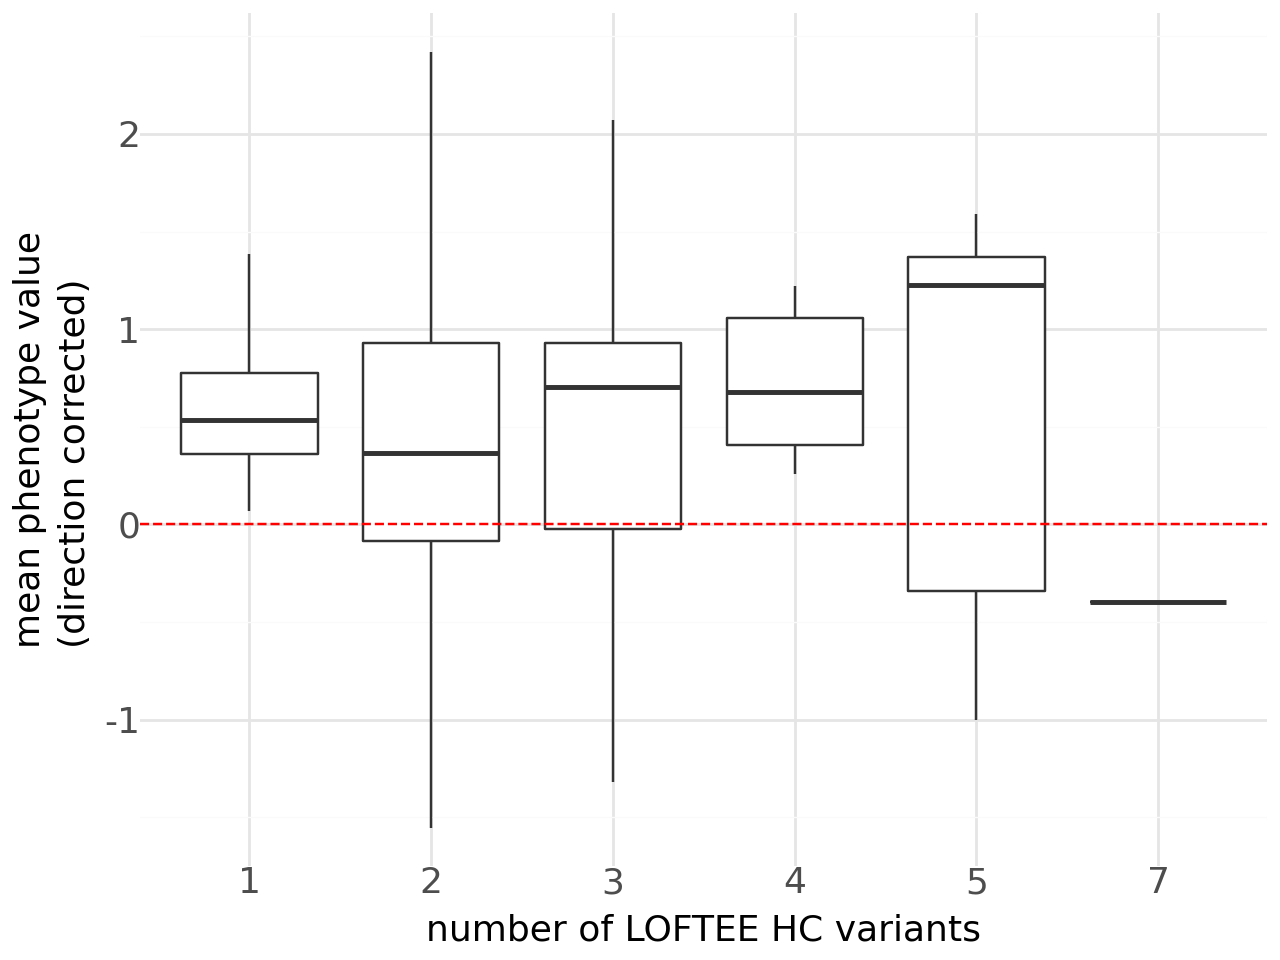

In [11]:
(
    ggplot(
        loftee_pheno_region, 
        aes(x='burden_categories', y='mean_pheno_value_dircorr')
    )
    + geom_boxplot(outlier_shape=None)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
loftee_pheno_avg_region = (
    loftee_pheno_region
    .group_by(['burden_categories'])
    .agg(
        n_individuals = pl.len().cast(pl.Int32),
        mean_pheno_value = pl.col('mean_pheno_value_dircorr').mean().cast(pl.Float32),
        std_pheno_value = pl.col('mean_pheno_value_dircorr').std().cast(pl.Float32),
        ci_quant_lower = pl.col('mean_pheno_value_dircorr').quantile(0.025).cast(pl.Float32),
        ci_quant_upper = pl.col('mean_pheno_value_dircorr').quantile(0.975).cast(pl.Float32),
    )
    .with_columns(
        ci_se_lower = pl.col('mean_pheno_value') - 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt()),
        ci_se_upper = pl.col('mean_pheno_value') + 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt())
    )
)

loftee_pheno_avg_region

burden_categories,n_individuals,mean_pheno_value,std_pheno_value,ci_quant_lower,ci_quant_upper,ci_se_lower,ci_se_upper
cat,i32,f32,f32,f32,f32,f64,f64
"""1""",670,0.634546,0.46483,0.153999,1.909485,0.599348,0.669743
"""4""",14,0.863245,0.595248,0.260247,2.128207,0.551435,1.175055
"""5""",5,0.569518,1.163306,-1.000978,1.589464,-0.450164,1.589201
"""2""",274,0.448898,0.932357,-1.318035,2.51763,0.338499,0.559296
"""7""",1,-0.396249,null,-0.396249,-0.396249,null,null
"""3""",69,0.450169,0.875729,-1.318539,1.936442,0.243535,0.656802


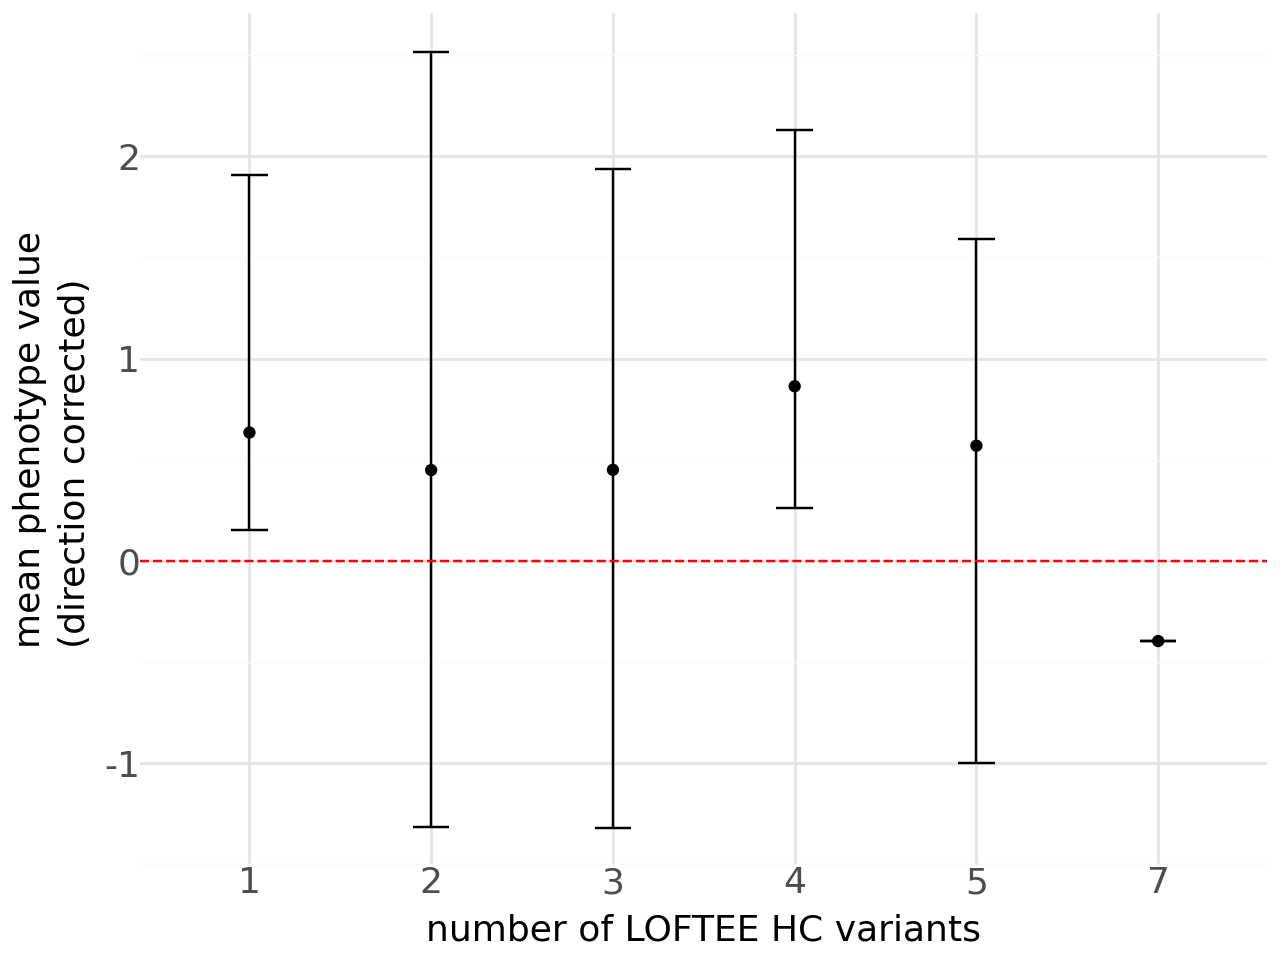

In [14]:
(
    ggplot(
        loftee_pheno_avg_region,
        aes(x='burden_categories', y='mean_pheno_value')
    )
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin='ci_quant_lower', ymax='ci_quant_upper'), width=0.2)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [8]:
loftee_pheno = (
    long_phenos_int
    .join(
        long_gt,
        on=['sample', 'region'],
        how='inner'
    )
    .with_columns(
        pheno_value_dircorr = pl.col('pheno_value_int')*pl.col('loftee_corr_dir'),
        burden_categories = pl.col('burden').cast(pl.Utf8).cast(pl.Categorical)
    )
)

loftee_pheno

sample,phenotype,pheno_value_int,region,loftee_corr_dir,burden,pheno_value_dircorr,burden_categories
str,str,f64,str,f64,i32,f64,cat
"""1004402""","""eosinophill_percentage_int""",2.380286,"""ENSG00000131018""",1.0,1,2.380286,"""1"""
"""1020468""","""eosinophill_percentage_int""",0.19717,"""ENSG00000131018""",1.0,1,0.19717,"""1"""
"""1065547""","""eosinophill_percentage_int""",0.513133,"""ENSG00000131018""",1.0,1,0.513133,"""1"""
"""1107093""","""eosinophill_percentage_int""",0.840166,"""ENSG00000131018""",1.0,1,0.840166,"""1"""
"""1110691""","""eosinophill_percentage_int""",-1.650151,"""ENSG00000121966""",-1.0,1,1.650151,"""1"""
…,…,…,…,…,…,…,…
"""5334558""","""white_blood_cell_leukocyte_cou…",0.374641,"""ENSG00000064932""",1.0,1,0.374641,"""1"""
"""5459060""","""white_blood_cell_leukocyte_cou…",1.54302,"""ENSG00000064932""",1.0,1,1.54302,"""1"""
"""5792736""","""white_blood_cell_leukocyte_cou…",0.822239,"""ENSG00000064932""",1.0,1,0.822239,"""1"""


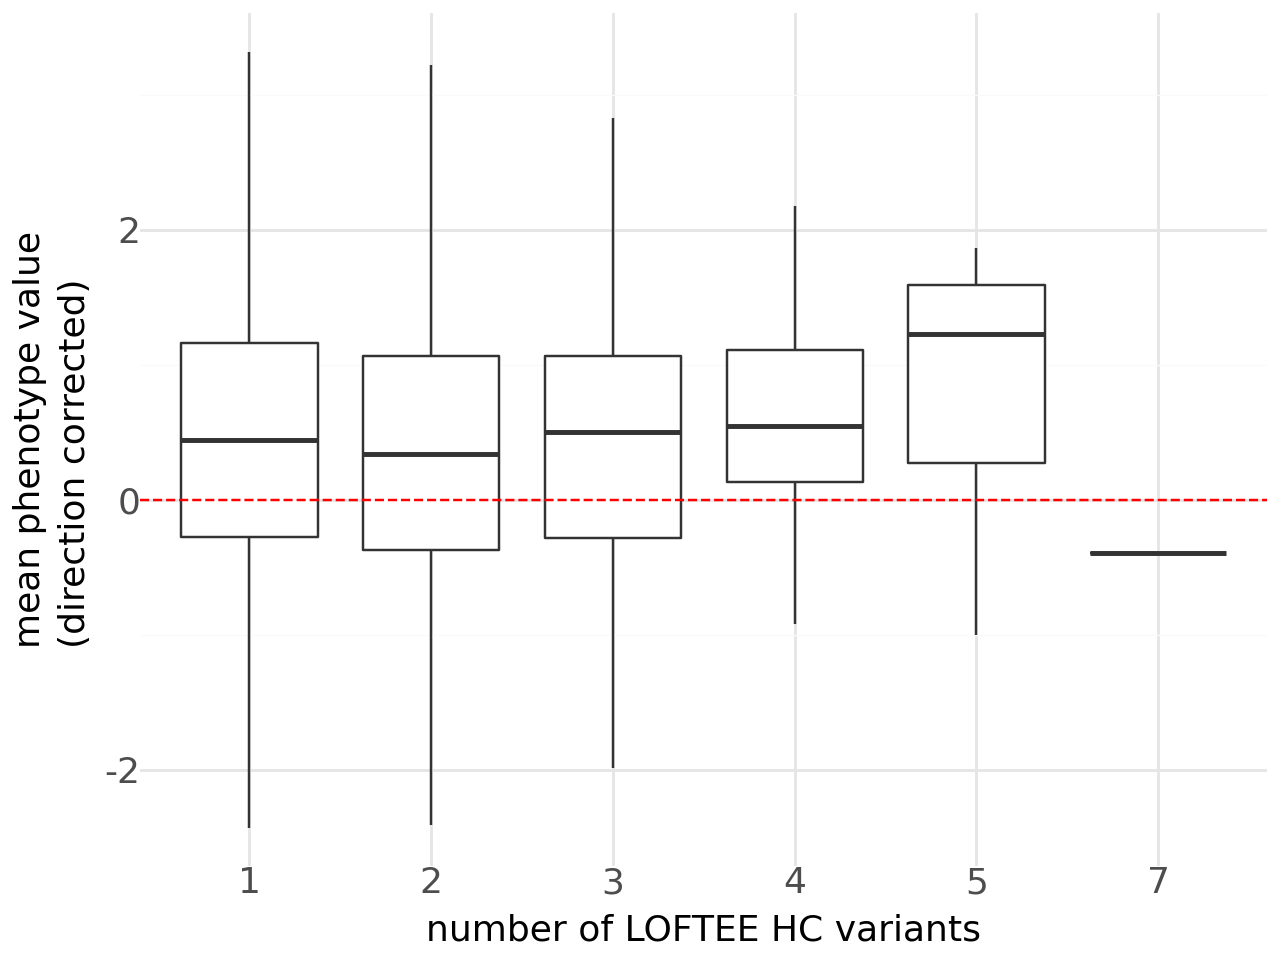

In [23]:
(
    ggplot(
        loftee_pheno, 
        # loftee_pheno.filter(pl.col('burden')==1), 
        aes(x='burden_categories', y='pheno_value_dircorr')
    )
    + geom_boxplot(outlier_shape=None)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [21]:
loftee_pheno_avg = (
    loftee_pheno
    .group_by(['burden_categories'])
    .agg(
        n_individuals = pl.len().cast(pl.Int32),
        mean_pheno_value = pl.col('pheno_value_dircorr').mean().cast(pl.Float32),
        std_pheno_value = pl.col('pheno_value_dircorr').std().cast(pl.Float32),
        ci_quant_lower = pl.col('pheno_value_dircorr').quantile(0.025).cast(pl.Float32),
        ci_quant_upper = pl.col('pheno_value_dircorr').quantile(0.975).cast(pl.Float32),
    )
    .with_columns(
        ci_se_lower = pl.col('mean_pheno_value') - 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt()),
        ci_se_upper = pl.col('mean_pheno_value') + 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt())
    )
)

loftee_pheno_avg

burden_categories,n_individuals,mean_pheno_value,std_pheno_value,ci_quant_lower,ci_quant_upper,ci_se_lower,ci_se_upper
cat,i32,f32,f32,f32,f32,f64,f64
"""1""",74789,0.448126,1.070348,-1.637177,2.567491,0.440454,0.455797
"""4""",31,0.632257,0.993812,-0.89248,2.619945,0.282409,0.982105
"""5""",7,0.829798,1.088355,-1.000978,1.863754,0.023533,1.636062
"""2""",961,0.356733,1.125556,-1.873744,2.51763,0.285569,0.427897
"""3""",168,0.382869,1.129064,-1.895261,2.55736,0.212135,0.553603
"""7""",1,-0.396249,null,-0.396249,-0.396249,null,null


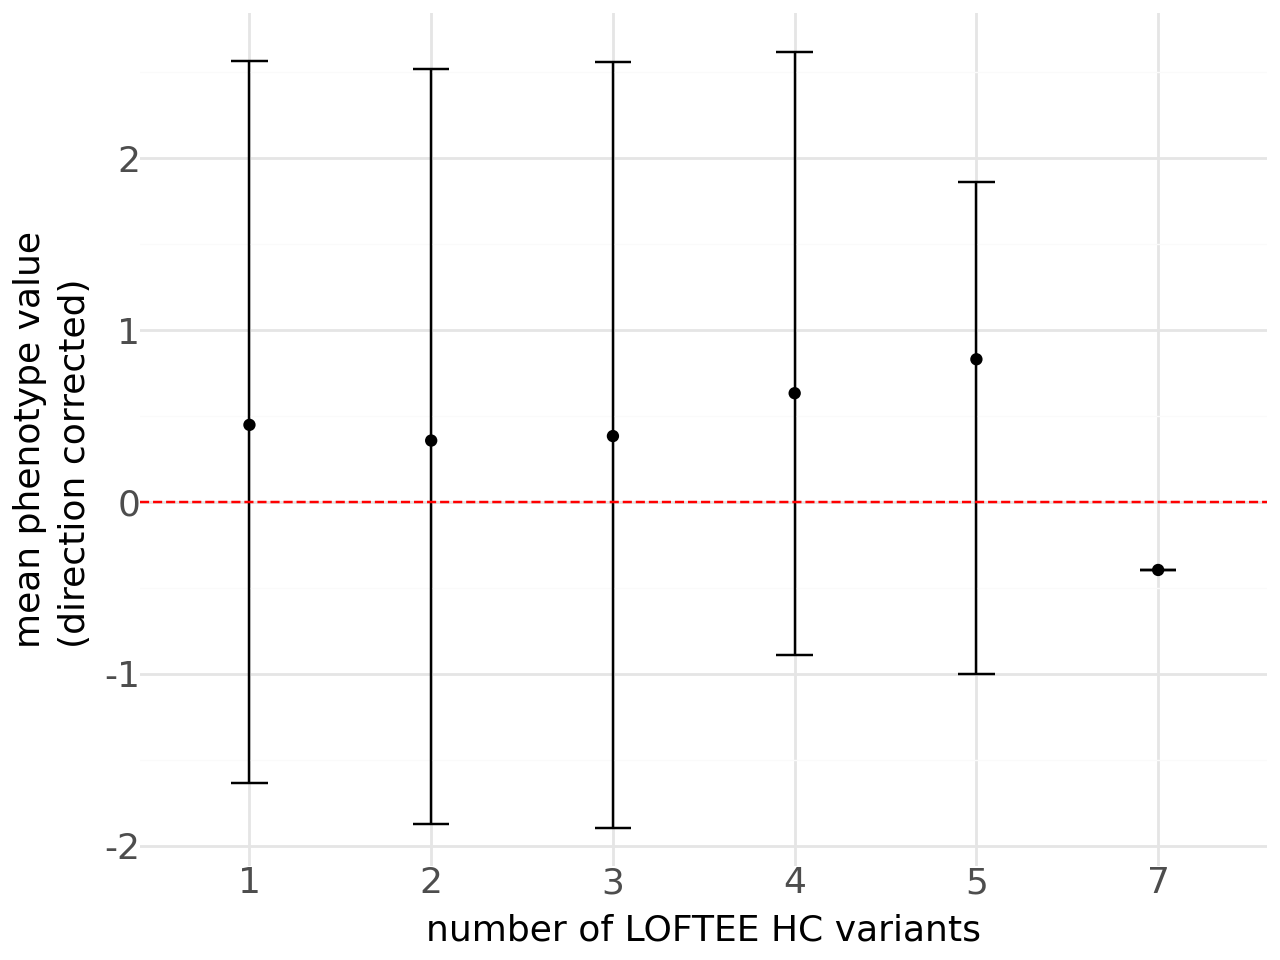

In [ ]:
(
    ggplot(
        loftee_pheno_avg,
        aes(x='burden_categories', y='mean_pheno_value')
    )
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin='ci_quant_lower', ymax='ci_quant_upper'), width=0.2)
    + geom_hline(yintercept=0, linetype='dashed', color='red')
    + labs(
        x = 'number of LOFTEE HC variants',
        y = 'mean phenotype value\n(direction corrected)'
    )
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)